In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn networkx xgboost lightgbm shap streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 32.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gossipcop_fake.csv to gossipcop_fake.csv
Saving gossipcop_real.csv to gossipcop_real.csv
Saving politifact_fake.csv to politifact_fake.csv
Saving politifact_real.csv to politifact_real.csv


In [ ]:
import pandas as pd
import numpy as np

gossip_fake = pd.read_csv("gossipcop_fake.csv")
gossip_real = pd.read_csv("gossipcop_real.csv")
politifact_fake = pd.read_csv("politifact_fake.csv")
politifact_real = pd.read_csv("politifact_real.csv")

print("GossipCop Fake:", gossip_fake.shape)
print("GossipCop Real:", gossip_real.shape)
print("PolitiFact Fake:", politifact_fake.shape)
print("PolitiFact Real:", politifact_real.shape)

GossipCop Fake: (5323, 4)
GossipCop Real: (16817, 4)
PolitiFact Fake: (432, 4)
PolitiFact Real: (624, 4)


In [ ]:
gossip_fake["label"] = 1
gossip_real["label"] = 0
politifact_fake["label"] = 1
politifact_real["label"] = 0

gossip_fake["source"] = "gossipcop"
gossip_real["source"] = "gossipcop"
politifact_fake["source"] = "politifact"
politifact_real["source"] = "politifact"

In [ ]:
df = pd.concat(
    [gossip_fake, gossip_real, politifact_fake, politifact_real],
    ignore_index=True
)

print(df.shape)
df.head()

(23196, 6)


,id,news_url,title,tweet_ids,label,source
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...,1,gossipcop
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...,1,gossipcop
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...,1,gossipcop
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...,1,gossipcop
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...,1,gossipcop


In [ ]:
df.to_csv("combined_fakenewsnet.csv", index=False)
print("Combined dataset saved successfully.")

Combined dataset saved successfully.


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         23196 non-null  object
 1   news_url   22866 non-null  object
 2   title      23196 non-null  object
 3   tweet_ids  21695 non-null  object
 4   label      23196 non-null  int64 
 5   source     23196 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


,id,news_url,title,tweet_ids,label,source
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...,1,gossipcop
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...,1,gossipcop
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...,1,gossipcop
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...,1,gossipcop
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...,1,gossipcop


STEP 3: DATA CLEANING & EXPLORATORY DATA ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Dataset Shape
(23196, 6)

Columns
['id', 'news_url', 'title', 'tweet_ids', 'label', 'source']

Data Types
id           object
news_url     object
title        object
tweet_ids    object
label         int64
source       object
dtype: object

Missing Values
id              0
news_url      330
title           0
tweet_ids    1501
label           0
source          0
dtype: int64

Duplicate Rows
0


In [ ]:
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {after}")
print(f"Duplicates removed   : {before-after}")

Rows before cleaning : 23196
Rows after cleaning  : 23196
Duplicates removed   : 0


In [ ]:
print(df.isnull().sum())

id              0
news_url      330
title           0
tweet_ids    1501
label           0
source          0
dtype: int64


In [ ]:
df["news_url"] = df["news_url"].fillna("Unknown")
df["title"] = df["title"].fillna("No Title")
df["tweet_ids"] = df["tweet_ids"].fillna("")

In [ ]:
print(df.isnull().sum())

id           0
news_url     0
title        0
tweet_ids    0
label        0
source       0
dtype: int64


Exploratory Data Analysis (EDA)

In [ ]:
df.describe(include="all")

,id,news_url,title,tweet_ids,label,source
count,23196,23196,23196,23196,23196.000000,23196
unique,23194,21659,21724,21598,NaN,2
top,politifact14920,Unknown,Connecting People Through News,,NaN,gossipcop
freq,2,330,20,1501,NaN,22140
mean,NaN,NaN,NaN,NaN,0.248103,NaN
std,NaN,NaN,NaN,NaN,0.431921,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,NaN,0.000000,NaN


label
0    17441
1     5755
Name: count, dtype: int64


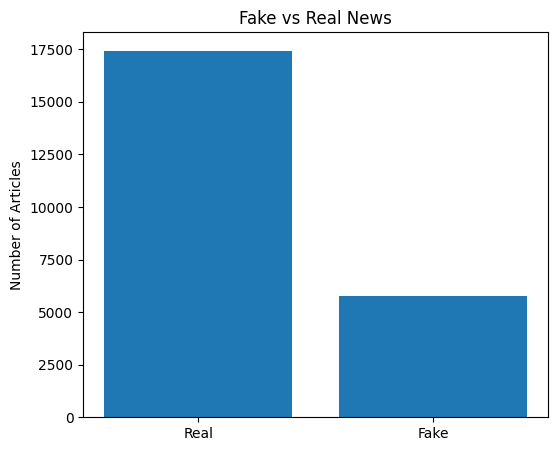

In [ ]:
label_counts = df["label"].value_counts()

print(label_counts)

plt.figure(figsize=(6,5))

plt.bar(
    ["Real","Fake"],
    [label_counts[0],label_counts[1]]
)

plt.title("Fake vs Real News")
plt.ylabel("Number of Articles")

plt.show()

source
gossipcop     22140
politifact     1056
Name: count, dtype: int64


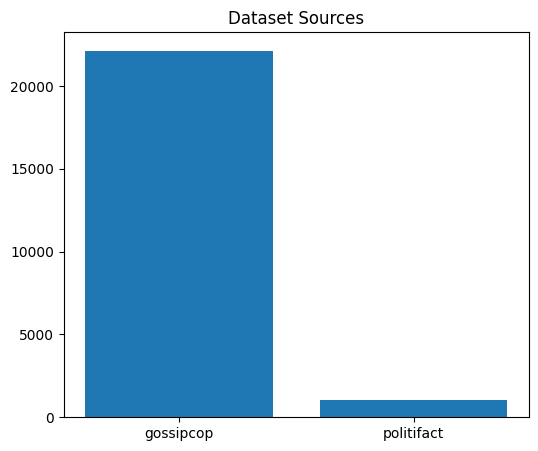

In [ ]:
source_counts = df["source"].value_counts()

print(source_counts)

plt.figure(figsize=(6,5))

plt.bar(source_counts.index,
        source_counts.values)

plt.title("Dataset Sources")

plt.show()

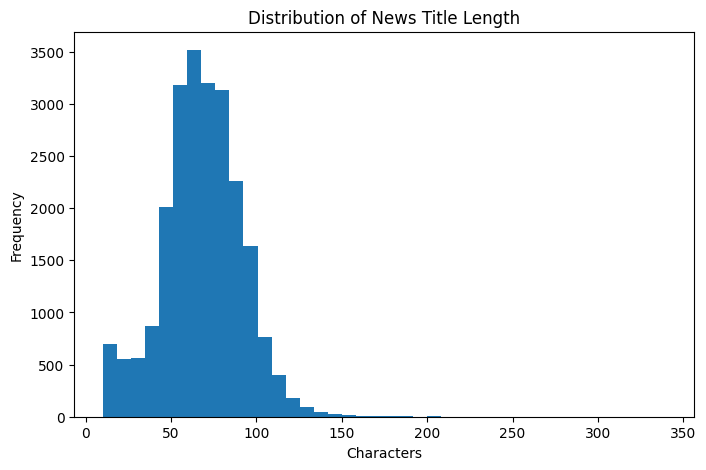

In [ ]:
df["title_length"] = df["title"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df["title_length"], bins=40)

plt.title("Distribution of News Title Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [ ]:
df["tweet_count"] = df["tweet_ids"].apply(
    lambda x: len(str(x).split("\t")) if str(x).strip() else 0
)

df[["tweet_count"]].describe()

,tweet_count
count,23196.000000
mean,88.956803
std,488.694592
min,0.000000
25%,11.000000
50%,37.000000
75%,65.000000
max,29060.000000


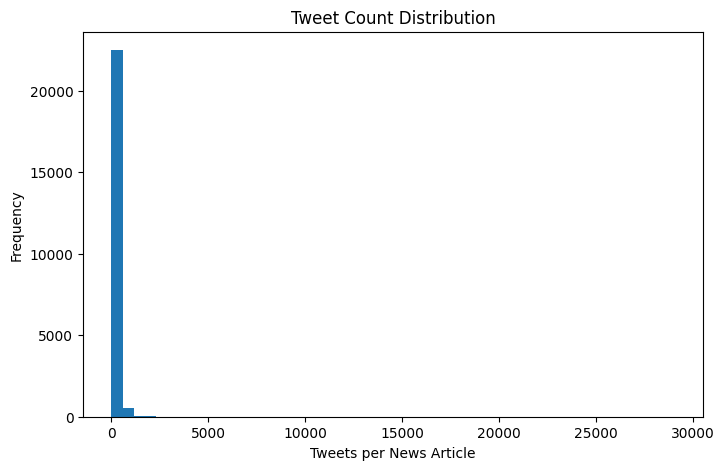

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["tweet_count"], bins=50)

plt.title("Tweet Count Distribution")

plt.xlabel("Tweets per News Article")

plt.ylabel("Frequency")

plt.show()

In [ ]:
df.to_csv("clean_fakenewsnet.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


STEP 4: FEATURE ENGINEERING

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [ ]:
df["word_count"] = df["title"].apply(lambda x: len(str(x).split()))

df[["word_count"]].describe()

,word_count
count,23196.000000
mean,11.161192
std,3.977693
min,1.000000
25%,9.000000
50%,11.000000
75%,14.000000
max,53.000000


In [ ]:
df["avg_word_length"] = df["title"].apply(
    lambda x: np.mean([len(word) for word in str(x).split()])
    if len(str(x).split()) > 0 else 0
)

df[["avg_word_length"]].describe()

,avg_word_length
count,23196.000000
mean,5.325629
std,1.147572
min,2.000000
25%,4.750000
50%,5.230769
75%,5.750000
max,70.000000


In [ ]:
df["uppercase_words"] = df["title"].apply(
    lambda x: sum(word.isupper() for word in str(x).split())
)

df[["uppercase_words"]].describe()

,uppercase_words
count,23196.000000
mean,0.263451
std,0.803395
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,23.000000


In [ ]:
import string

df["punctuation_count"] = df["title"].apply(
    lambda x: sum(c in string.punctuation for c in str(x))
)

df[["punctuation_count"]].describe()

,punctuation_count
count,23196.000000
mean,1.494439
std,1.645891
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,23.000000


In [ ]:
encoder = LabelEncoder()

df["source_encoded"] = encoder.fit_transform(df["source"])

df[["source", "source_encoded"]].head()

,source,source_encoded
0,gossipcop,0
1,gossipcop,0
2,gossipcop,0
3,gossipcop,0
4,gossipcop,0


In [ ]:
df["tweet_count_log"] = np.log1p(df["tweet_count"])

df[["tweet_count", "tweet_count_log"]].head()

,tweet_count,tweet_count_log
0,97,4.584967
1,15,2.772589
2,86,4.465908
3,14,2.708050
4,66,4.204693


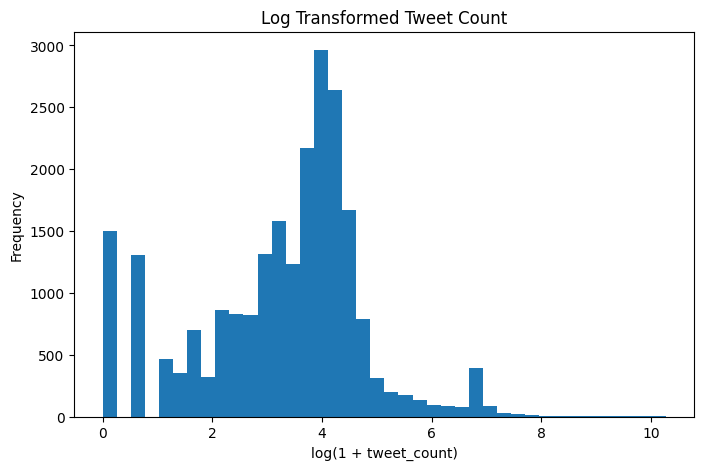

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["tweet_count_log"], bins=40)

plt.title("Log Transformed Tweet Count")

plt.xlabel("log(1 + tweet_count)")

plt.ylabel("Frequency")

plt.show()

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X_text = tfidf.fit_transform(df["title"])

print(X_text.shape)

(23196, 3000)


In [ ]:
numeric_features = df[
    [
        "title_length",
        "word_count",
        "avg_word_length",
        "uppercase_words",
        "punctuation_count",
        "tweet_count_log",
        "source_encoded"
    ]
]

numeric_features.head()

,title_length,word_count,avg_word_length,uppercase_words,punctuation_count,tweet_count_log,source_encoded
0,56,9,5.333333,0,1,4.584967,0
1,98,15,5.600000,0,2,2.772589,0
2,53,9,5.000000,0,0,4.465908,0
3,80,13,5.230769,0,1,2.708050,0
4,45,8,4.750000,0,0,4.204693,0


In [ ]:
from scipy.sparse import hstack

X = hstack([X_text, numeric_features.values])

y = df["label"]

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (23196, 3007)
Labels Shape: (23196,)


In [ ]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved.")

TF-IDF vectorizer saved.


STEP 5 : BASELINE MODEL
Logistic Regression

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (18556, 3007)
Testing Samples  : (4640, 3007)


In [ ]:
lr = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

lr.fit(X_train, y_train)

print("Improved Logistic Regression trained successfully.")

Improved Logistic Regression trained successfully.


In [ ]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)

print("Accuracy :", round(accuracy,4))

print("Precision:", round(precision,4))

print("Recall   :", round(recall,4))

print("F1 Score :", round(f1,4))

print("ROC AUC  :", round(roc_auc,4))

print("="*50)

Accuracy : 0.8142
Precision: 0.5976
Recall   : 0.7689
F1 Score : 0.6725
ROC AUC  : 0.8739


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      3489
           1       0.60      0.77      0.67      1151

    accuracy                           0.81      4640
   macro avg       0.76      0.80      0.77      4640
weighted avg       0.84      0.81      0.82      4640



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2893  596]
 [ 266  885]]


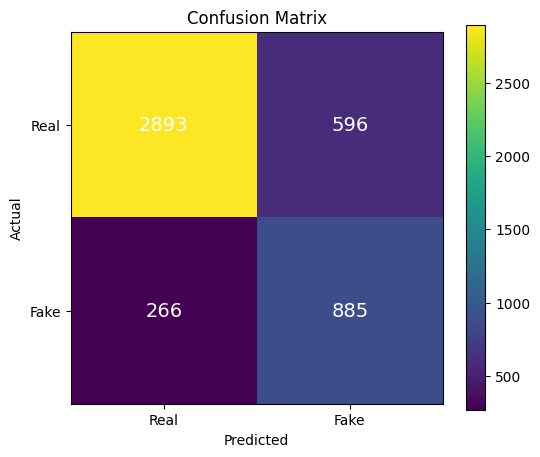

In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Real","Fake"])

plt.yticks([0,1],["Real","Fake"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                 ha="center",
                 va="center",
                 color="white",
                 fontsize=14)

plt.show()

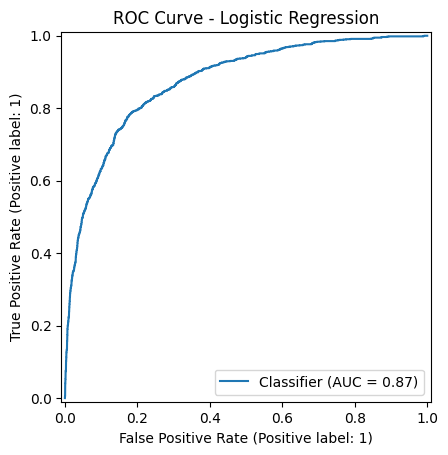

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)

print()

print("Average F1 Score:", scores.mean())

[0.6639478  0.66851925 0.65941748 0.67487495 0.5374376 ]

Average F1 Score: 0.6408394166028641


In [ ]:
import joblib

joblib.dump(lr, "logistic_regression.pkl")

print("Baseline model saved.")

Baseline model saved.



STEP 6: ADVANCED MODEL 1 - RANDOM FOREST

In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Accuracy : 0.8332
Precision: 0.6449
Recall   : 0.7289
F1 Score : 0.6843
ROC AUC  : 0.8885


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      3489
           1       0.64      0.73      0.68      1151

    accuracy                           0.83      4640
   macro avg       0.78      0.80      0.79      4640
weighted avg       0.84      0.83      0.84      4640



In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[3027  462]
 [ 312  839]]


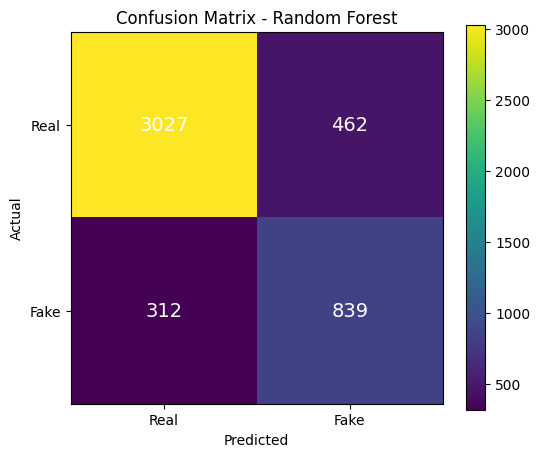

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(rf_cm)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xticks([0,1],["Real","Fake"])
plt.yticks([0,1],["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(rf_cm[i,j]), ha="center", va="center", color="white", fontsize=14)

plt.show()

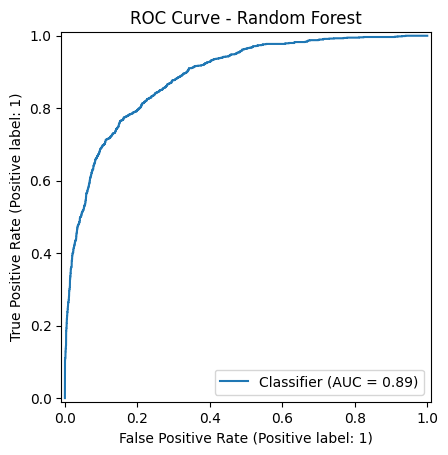

In [ ]:
RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve - Random Forest")
plt.show()

In [ ]:
joblib.dump(rf, "random_forest.pkl")
print("Random Forest model saved.")

Random Forest model saved.


Advanced Model 2 XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, xgb_pred),4))
print("Precision:", round(precision_score(y_test, xgb_pred),4))
print("Recall   :", round(recall_score(y_test, xgb_pred),4))
print("F1 Score :", round(f1_score(y_test, xgb_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, xgb_prob),4))

Accuracy : 0.8722
Precision: 0.7943
Recall   : 0.6542
F1 Score : 0.7175
ROC AUC  : 0.9103


In [ ]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      3489
           1       0.79      0.65      0.72      1151

    accuracy                           0.87      4640
   macro avg       0.84      0.80      0.82      4640
weighted avg       0.87      0.87      0.87      4640



In [ ]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(xgb_cm)

[[3294  195]
 [ 398  753]]


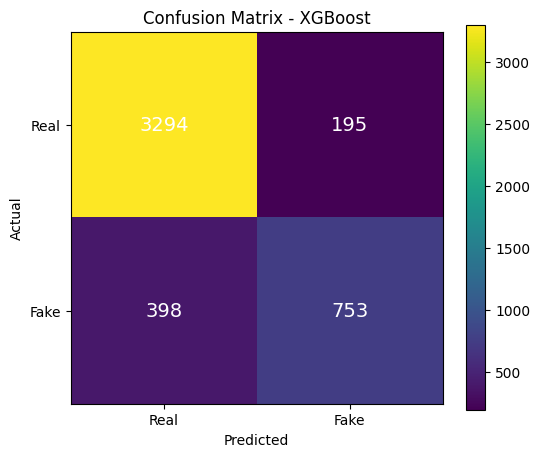

In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(xgb_cm)

plt.title("Confusion Matrix - XGBoost")

plt.colorbar()

plt.xticks([0,1],["Real","Fake"])
plt.yticks([0,1],["Real","Fake"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(xgb_cm[i,j]),
            ha="center",
            va="center",
            color="white",
            fontsize=14
        )

plt.show()

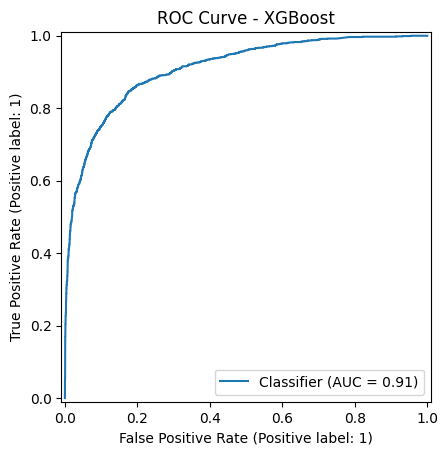

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob
)

plt.title("ROC Curve - XGBoost")

plt.show()

In [ ]:
joblib.dump(xgb,"xgboost_model.pkl")

print("XGBoost model saved.")

XGBoost model saved.


STEP 8: ADVANCED MODEL 3 - LIGHTGBM

In [ ]:

!pip install lightgbm -q

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train, y_train)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Number of positive: 4604, number of negative: 13952
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.304819 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33685
[LightGBM] [Info] Number of data points in the train set: 18556, number of used features: 1462
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, lgbm_pred), 4))
print("Precision:", round(precision_score(y_test, lgbm_pred), 4))
print("Recall   :", round(recall_score(y_test, lgbm_pred), 4))
print("F1 Score :", round(f1_score(y_test, lgbm_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, lgbm_prob), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8502
Precision: 0.6647
Recall   : 0.7993
F1 Score : 0.7258
ROC AUC  : 0.9108


In [ ]:
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      3489
           1       0.66      0.80      0.73      1151

    accuracy                           0.85      4640
   macro avg       0.80      0.83      0.81      4640
weighted avg       0.86      0.85      0.85      4640



In [ ]:
lgbm_cm = confusion_matrix(y_test, lgbm_pred)
print(lgbm_cm)

[[3025  464]
 [ 231  920]]


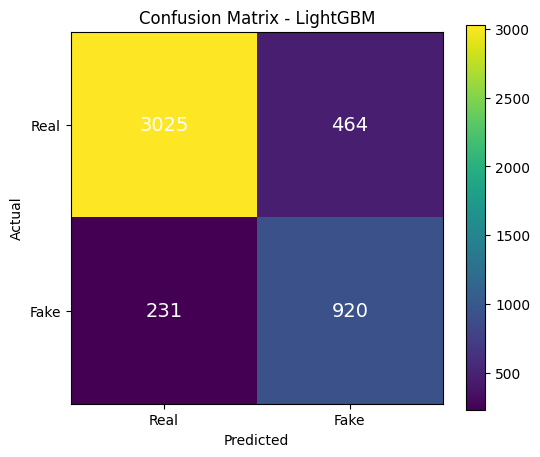

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(lgbm_cm)
plt.title("Confusion Matrix - LightGBM")
plt.colorbar()
plt.xticks([0,1],["Real","Fake"])
plt.yticks([0,1],["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(lgbm_cm[i,j]), ha="center", va="center", color="white", fontsize=14)

plt.show()

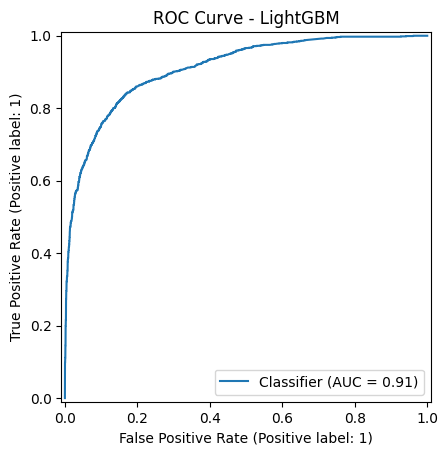

In [ ]:
RocCurveDisplay.from_predictions(y_test, lgbm_prob)
plt.title("ROC Curve - LightGBM")
plt.show()

In [ ]:
joblib.dump(lgbm, "lightgbm_model.pkl")
print("LightGBM model saved.")

LightGBM model saved.


Explainable AI using SHAP

In [ ]:
!pip install shap -q

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

In [ ]:
explainer = shap.TreeExplainer(lgbm)

print("SHAP Explainer created successfully.")

SHAP Explainer created successfully.


In [ ]:
X_sample = X_test[:300]

print("Sample shape:", X_sample.shape)

Sample shape: (300, 3007)


In [ ]:
shap_values = explainer(X_sample)

print("SHAP values calculated.")
print(shap_values.values.shape)

SHAP values calculated.
(300, 3007)


In [ ]:
tfidf_feature_names = tfidf.get_feature_names_out()

numeric_feature_names = [
    "title_length",
    "word_count",
    "avg_word_length",
    "uppercase_words",
    "punctuation_count",
    "tweet_count_log",
    "source_encoded"
]

feature_names = list(tfidf_feature_names) + numeric_feature_names

print("Total features:", len(feature_names))

Total features: 3007


In [ ]:
X_dense = X_sample.toarray()

print(X_dense.shape)

(300, 3007)


In [ ]:


raw_values = shap_values.values

print("Original SHAP shape:", raw_values.shape)

if len(raw_values.shape) == 3:
    values = raw_values[:, :, 1]
else:
    values = raw_values

print("Fixed SHAP shape:", values.shape)
print("X_dense shape:", X_dense.shape)

Original SHAP shape: (300, 3007)
Fixed SHAP shape: (300, 3007)
X_dense shape: (300, 3007)


In [ ]:
import pandas as pd
import numpy as np

X_dense = X_sample.toarray()
X_shap_df = pd.DataFrame(X_dense, columns=feature_names)

print(values.shape)
print(X_shap_df.shape)

(300, 3007)
(300, 3007)


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

X_dense = X_sample.toarray()
X_shap_df = pd.DataFrame(X_dense, columns=feature_names)

raw_values = shap_values.values

if sparse.issparse(raw_values):
    raw_values = raw_values.toarray()

raw_values = np.asarray(raw_values)

if raw_values.ndim == 3:
    values = raw_values[:, :, 1]
else:
    values = raw_values

values = np.asarray(values, dtype=float)

print("Final SHAP values shape:", values.shape)
print("Final X shape:", X_shap_df.shape)

Final SHAP values shape: (300, 3007)
Final X shape: (300, 3007)


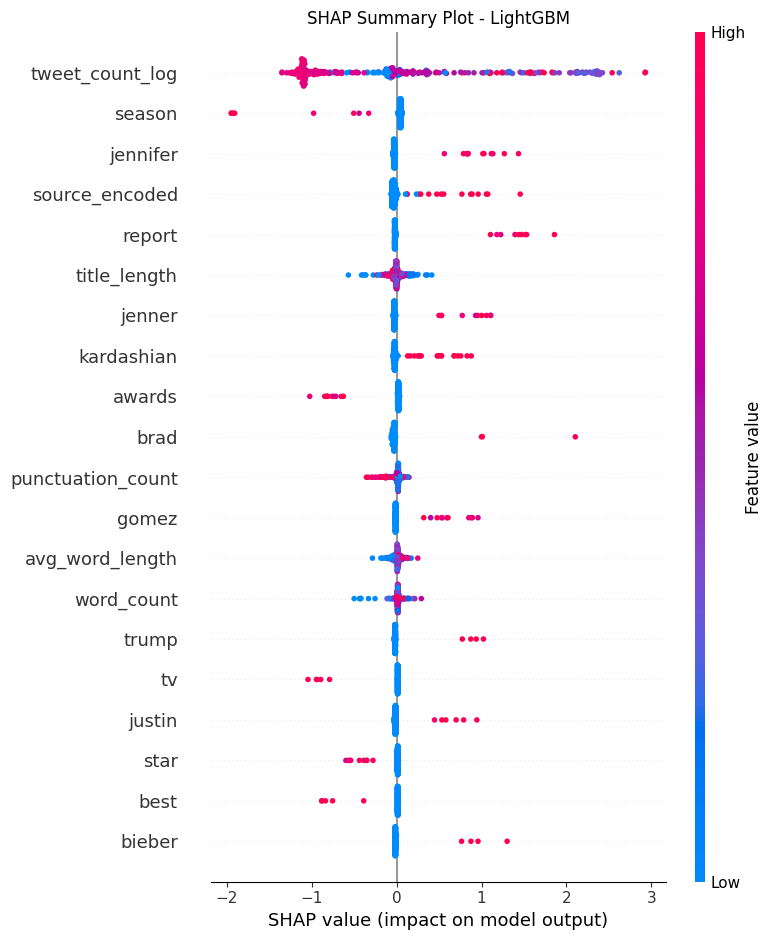

In [ ]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    values,
    X_shap_df.values,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - LightGBM")
plt.tight_layout()
plt.show()

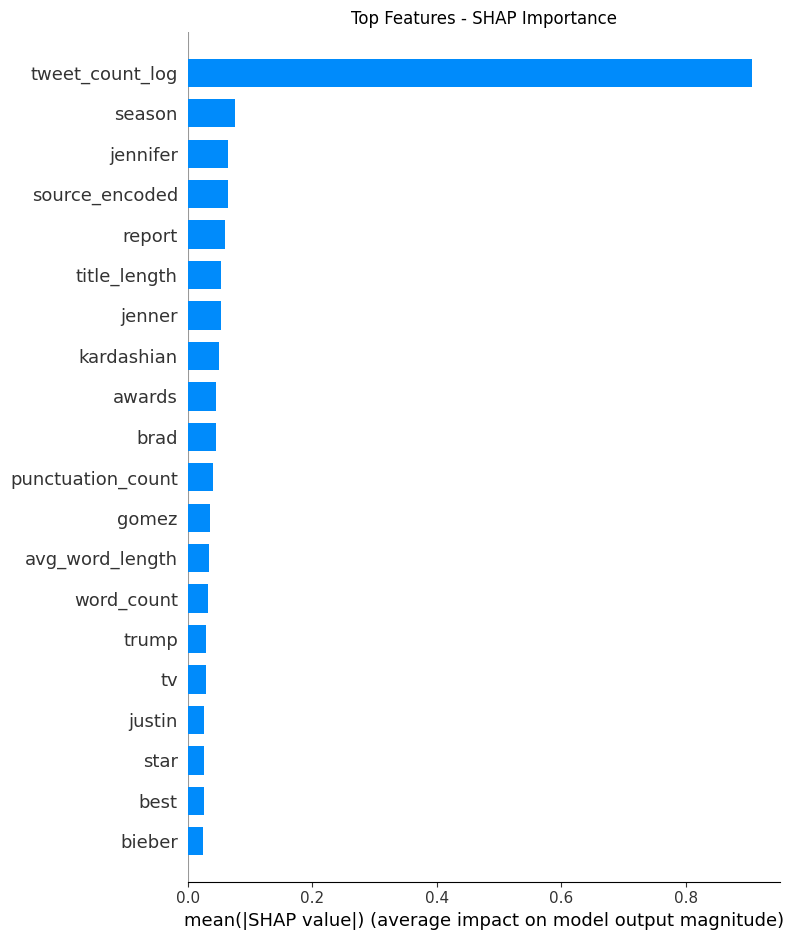

In [ ]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    values,
    X_shap_df.values,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Top Features - SHAP Importance")
plt.tight_layout()
plt.show()


Class Imbalance Handling with SMOTE

In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
smote_lgbm = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=31,
        random_state=42
    ))
])

smote_lgbm.fit(X_train, y_train)

smote_pred = smote_lgbm.predict(X_test)
smote_prob = smote_lgbm.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, smote_pred), 4))
print("Precision:", round(precision_score(y_test, smote_pred), 4))
print("Recall   :", round(recall_score(y_test, smote_pred), 4))
print("F1 Score :", round(f1_score(y_test, smote_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, smote_prob), 4))

print(classification_report(y_test, smote_pred))

[LightGBM] [Info] Number of positive: 13952, number of negative: 13952
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.042769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 73887
[LightGBM] [Info] Number of data points in the train set: 27904, number of used features: 2301
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8707
Precision: 0.7572
Recall   : 0.7046
F1 Score : 0.73
ROC AUC  : 0.913
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      3489
           1       0.76      0.70      0.73      1151

    accuracy                           0.87      4640
   macro avg       0.83      0.82      0.82      4640
weighted avg       0.87      0.87      0.87      4640



Hyperparameter Tuning for LightGBM

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [5, 8, 10, -1],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(class_weight="balanced", random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print("Best Parameters:")
print(lgbm_search.best_params_)

print("Best CV F1:")
print(lgbm_search.best_score_)

[LightGBM] [Info] Number of positive: 4604, number of negative: 13952
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.407753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40876
[LightGBM] [Info] Number of data points in the train set: 18556, number of used features: 2698
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best Parameters:
{'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV F1:
0.7443653146724639


In [ ]:
best_lgbm = lgbm_search.best_estimator_

best_pred = best_lgbm.predict(X_test)
best_prob = best_lgbm.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, best_pred), 4))
print("Precision:", round(precision_score(y_test, best_pred), 4))
print("Recall   :", round(recall_score(y_test, best_pred), 4))
print("F1 Score :", round(f1_score(y_test, best_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, best_prob), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8681
Precision: 0.7168
Recall   : 0.7741
F1 Score : 0.7444
ROC AUC  : 0.9249


Ensemble Voting Model

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("xgb", xgb),
        ("lgbm", lgbm)
    ],
    voting="soft",
    n_jobs=-1
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)
voting_prob = voting_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, voting_pred), 4))
print("Precision:", round(precision_score(y_test, voting_pred), 4))
print("Recall   :", round(recall_score(y_test, voting_pred), 4))
print("F1 Score :", round(f1_score(y_test, voting_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, voting_prob), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8767
Precision: 0.7494
Recall   : 0.7559
F1 Score : 0.7526
ROC AUC  : 0.9265


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final Results Table

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "SMOTE + LightGBM",
        "Tuned LightGBM",
        "Voting Ensemble"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, smote_pred),
        accuracy_score(y_test, best_pred),
        accuracy_score(y_test, voting_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgbm_pred),
        precision_score(y_test, smote_pred),
        precision_score(y_test, best_pred),
        precision_score(y_test, voting_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred),
        recall_score(y_test, smote_pred),
        recall_score(y_test, best_pred),
        recall_score(y_test, voting_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred),
        f1_score(y_test, smote_pred),
        f1_score(y_test, best_pred),
        f1_score(y_test, voting_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgbm_prob),
        roc_auc_score(y_test, smote_prob),
        roc_auc_score(y_test, best_prob),
        roc_auc_score(y_test, voting_prob)
    ]
})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8142,0.5976,0.7689,0.6725,0.8739
1,Random Forest,0.8332,0.6449,0.7289,0.6843,0.8885
2,XGBoost,0.8722,0.7943,0.6542,0.7175,0.9103
3,LightGBM,0.8502,0.6647,0.7993,0.7258,0.9108
4,SMOTE + LightGBM,0.8707,0.7572,0.7046,0.7300,0.9130
5,Tuned LightGBM,0.8681,0.7168,0.7741,0.7444,0.9249
6,Voting Ensemble,0.8767,0.7494,0.7559,0.7526,0.9265


Threshold Optimisation

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, voting_prob)

f1 = 2 * precision * recall / (precision + recall + 1e-10)

best_index = np.argmax(f1)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1:", f1[best_index])

Best Threshold: 0.49700499964545986
Best F1: 0.7555938037365794


In [ ]:
optimized_pred = (voting_prob >= best_threshold).astype(int)

print(classification_report(y_test, optimized_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3489
           1       0.75      0.76      0.76      1151

    accuracy                           0.88      4640
   macro avg       0.83      0.84      0.84      4640
weighted avg       0.88      0.88      0.88      4640



Calibration Curve

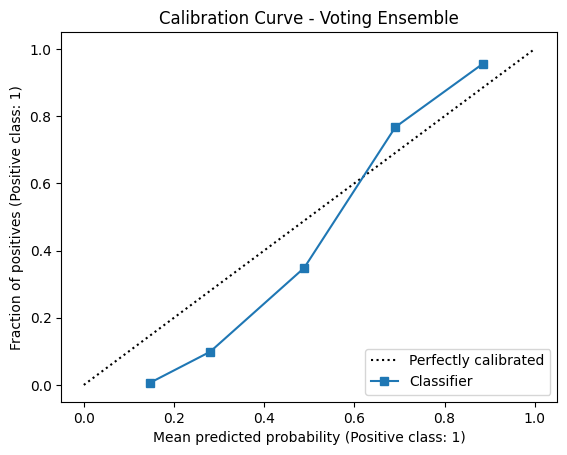

In [ ]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(
    y_test,
    voting_prob
)

plt.title("Calibration Curve - Voting Ensemble")
plt.show()

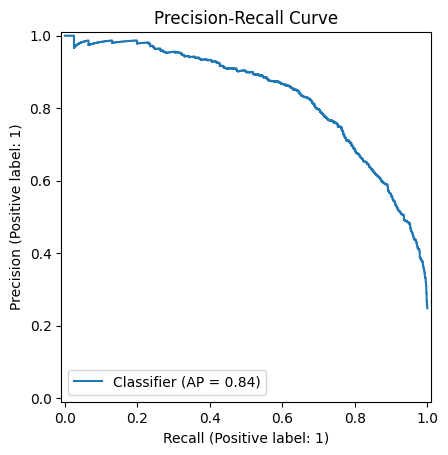

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    voting_prob
)

plt.title("Precision-Recall Curve")
plt.show()

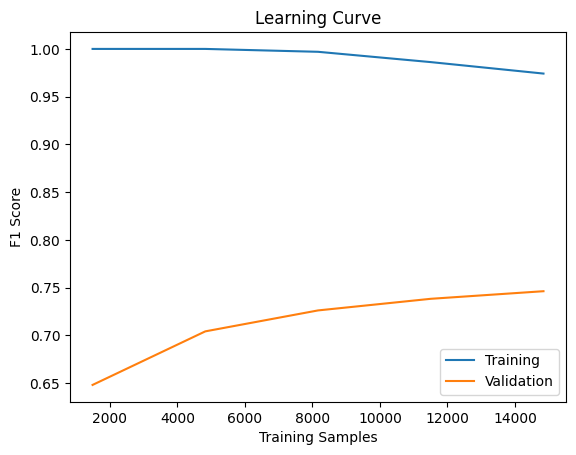

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_lgbm,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")

plt.xlabel("Training Samples")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()

In [ ]:
errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": voting_pred,
    "Probability": voting_prob
})

errors = errors[errors.Actual != errors.Predicted]

errors.head(20)

,Actual,Predicted,Probability
11667,0,1,0.647591
1080,1,0,0.310793
3130,1,0,0.254997
1036,1,0,0.495861
11792,0,1,0.567627
2883,1,0,0.306833
11811,0,1,0.542255
22016,0,1,0.592436
8884,0,1,0.598363
21635,0,1,0.572152


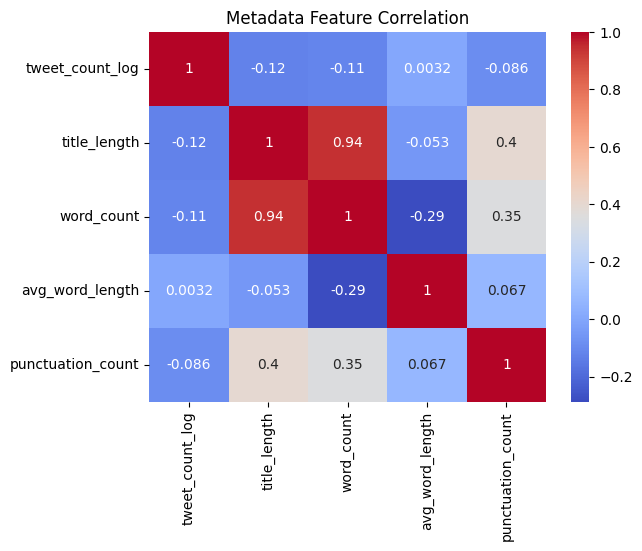

In [ ]:
import seaborn as sns

meta = df[[
    "tweet_count_log",
    "title_length",
    "word_count",
    "avg_word_length",
    "punctuation_count"
]]

sns.heatmap(meta.corr(), annot=True, cmap="coolwarm")

plt.title("Metadata Feature Correlation")
plt.show()

Network Analytics

Network 1: News Source Network

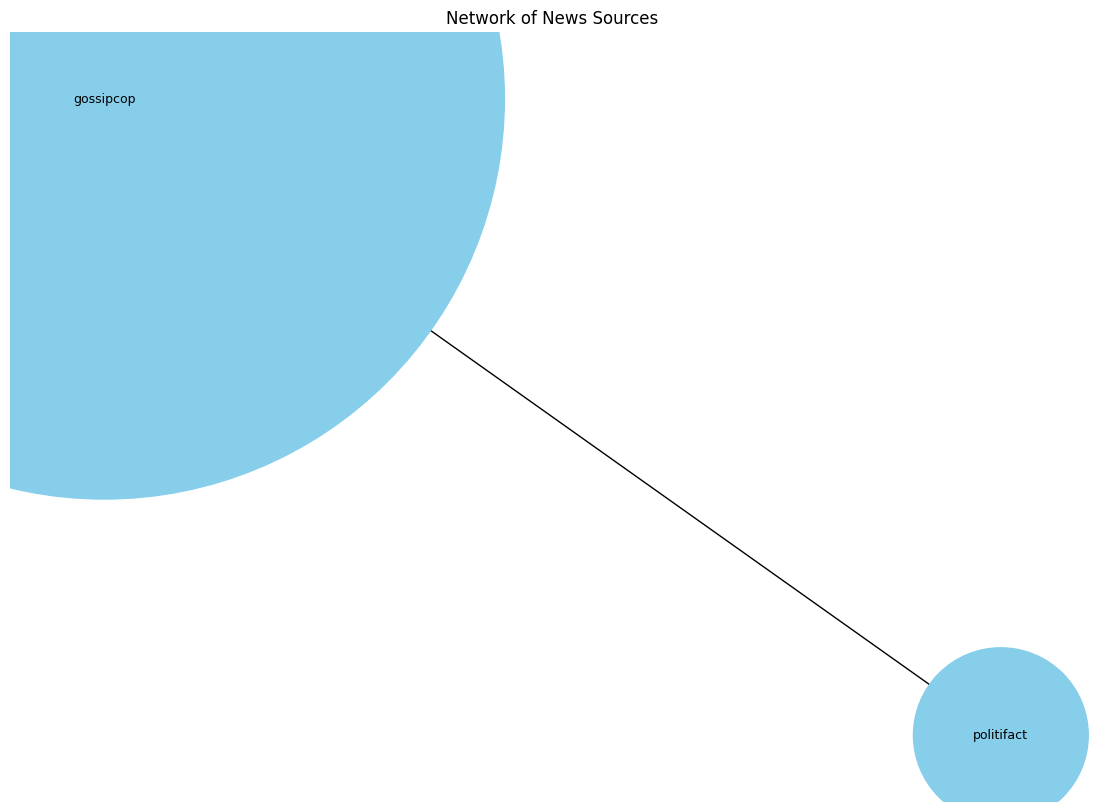

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

source_counts = (
    df.groupby("source")["label"]
      .count()
      .sort_values(ascending=False)
      .head(20)
)

G = nx.Graph()

for source in source_counts.index:
    G.add_node(source, size=source_counts[source])

sources = list(source_counts.index)

for i in range(len(sources)-1):
    G.add_edge(sources[i], sources[i+1])

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[G.nodes[n]["size"]*15 for n in G.nodes()],
    node_color="skyblue"
)

nx.draw_networkx_edges(G,pos)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

plt.title("Network of News Sources")

plt.axis("off")

plt.show()

Network 2: Fake vs Real Topic Network

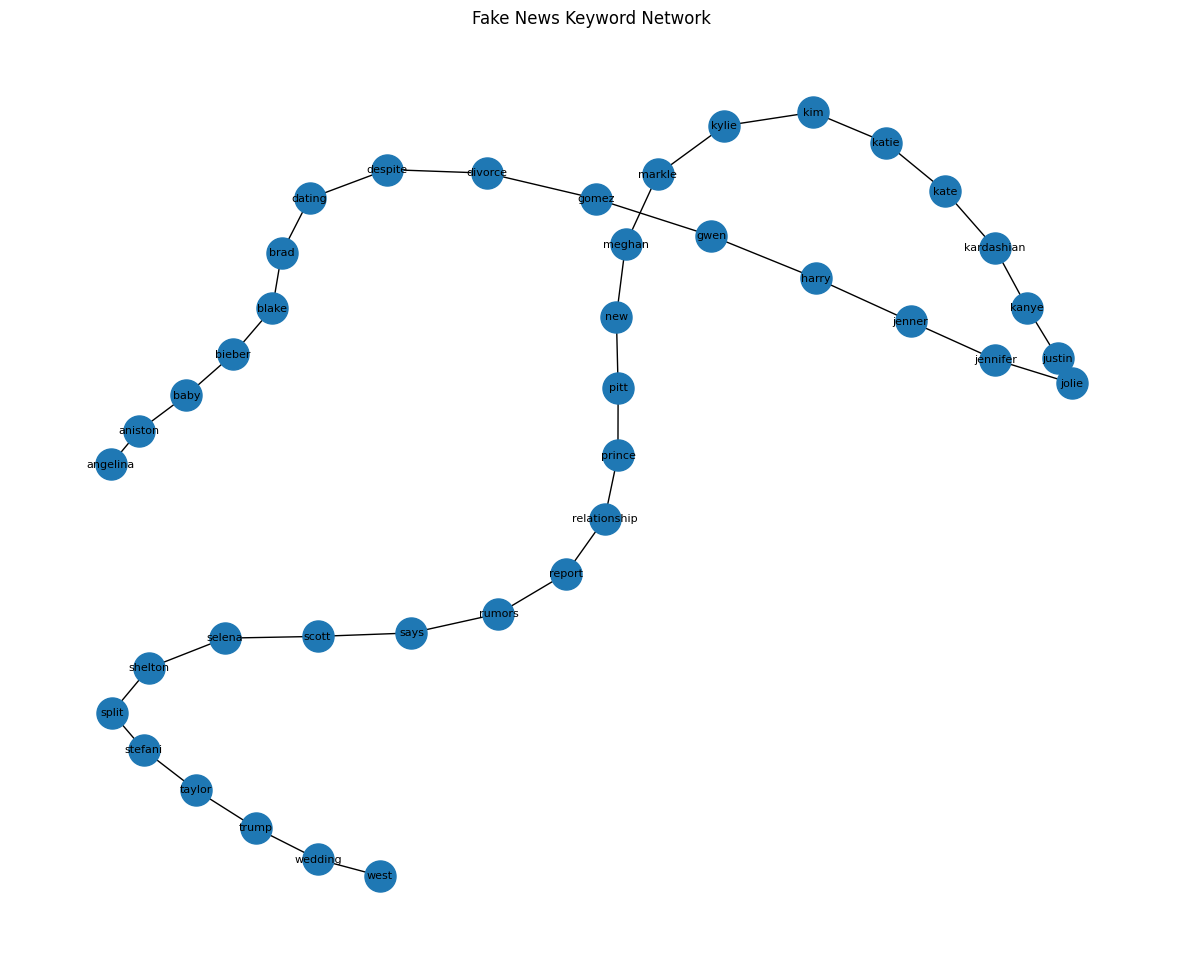

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fake_words = " ".join(df[df.label==1]["title"])

real_words = " ".join(df[df.label==0]["title"])

vectorizer = CountVectorizer(stop_words="english",max_features=40)

X_fake = vectorizer.fit_transform([fake_words])

fake_vocab = vectorizer.get_feature_names_out()

G = nx.Graph()

for word in fake_vocab:
    G.add_node(word)

for i in range(len(fake_vocab)-1):
    G.add_edge(fake_vocab[i],fake_vocab[i+1])

plt.figure(figsize=(15,12))

nx.draw_networkx(
    G,
    node_size=500,
    font_size=8
)

plt.title("Fake News Keyword Network")

plt.axis("off")

plt.show()

Network Centrality

In [ ]:
centrality = nx.degree_centrality(G)

centrality = pd.DataFrame({
    "Keyword":centrality.keys(),
    "Centrality":centrality.values()
})

centrality = centrality.sort_values(
    "Centrality",
    ascending=False
)

centrality.head(20)

,Keyword,Centrality
1,aniston,0.051282
2,baby,0.051282
3,bieber,0.051282
4,blake,0.051282
6,dating,0.051282
5,brad,0.051282
7,despite,0.051282
8,divorce,0.051282
24,new,0.051282
9,gomez,0.051282


Betweenness Centrality

In [ ]:
betweenness = nx.betweenness_centrality(G)

betweenness = pd.DataFrame({
    "Keyword":betweenness.keys(),
    "Betweenness":betweenness.values()
})

betweenness.sort_values(
    "Betweenness",
    ascending=False
).head(20)

,Keyword,Betweenness
19,katie,0.512821
20,kim,0.512821
21,kylie,0.510121
18,kate,0.510121
22,markle,0.504723
17,kardashian,0.504723
16,kanye,0.496626
23,meghan,0.496626
15,justin,0.485830
24,new,0.485830


Network Statistics

In [ ]:
print("Nodes:",G.number_of_nodes())

print("Edges:",G.number_of_edges())

print("Density:",nx.density(G))

print("Average Degree:",
      sum(dict(G.degree()).values())/
      G.number_of_nodes())

Nodes: 40
Edges: 39
Density: 0.05
Average Degree: 1.95


Model Stability (Cross Validation)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    best_lgbm,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Fold Scores")

print(scores)

print()

print("Mean:",scores.mean())

print("Std:",scores.std())

Fold Scores
[0.73870968 0.74279616 0.74933757 0.75226425 0.7396672 ]

Mean: 0.744554972627534
Std: 0.005356443560043157


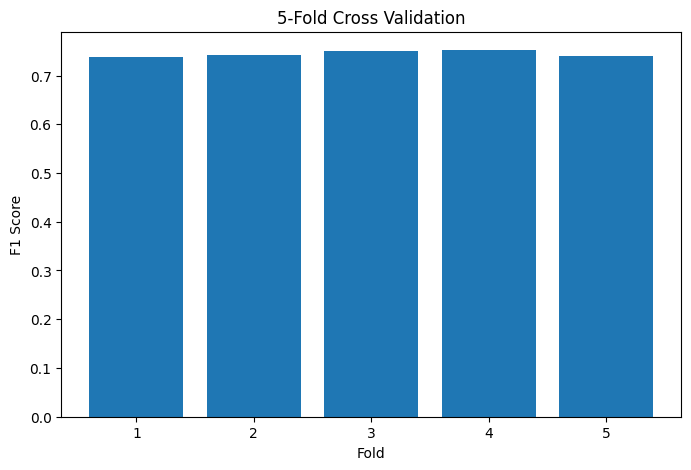

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    range(1,6),
    scores
)

plt.xlabel("Fold")

plt.ylabel("F1 Score")

plt.title("5-Fold Cross Validation")

plt.show()

ROC Curves of ALL Models

<Figure size 1000x800 with 0 Axes>

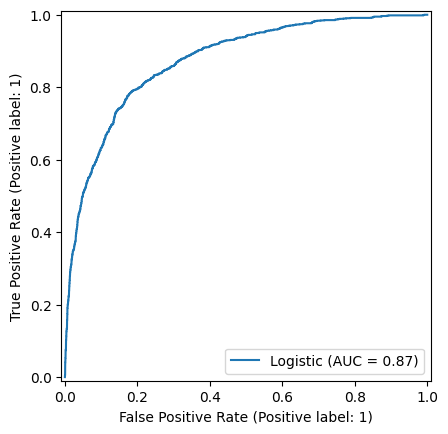

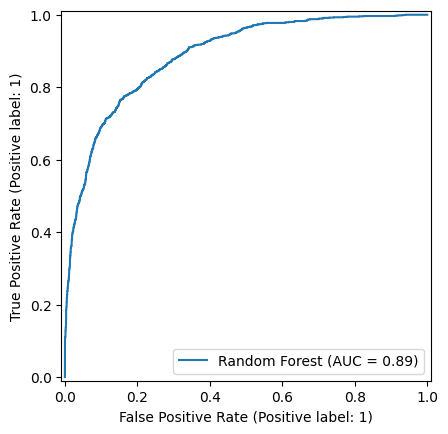

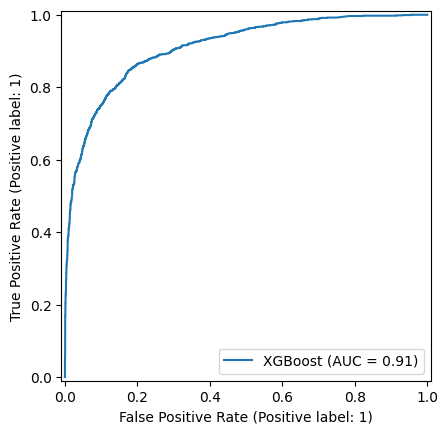

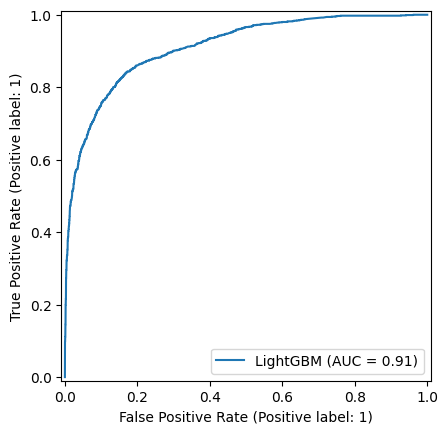

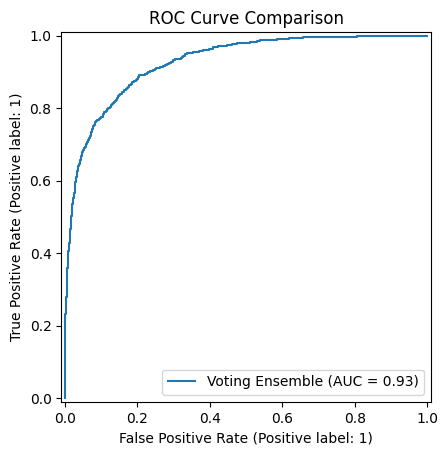

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10,8))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost"
)

RocCurveDisplay.from_predictions(
    y_test,
    lgbm_prob,
    name="LightGBM"
)

RocCurveDisplay.from_predictions(
    y_test,
    voting_prob,
    name="Voting Ensemble"
)

plt.title("ROC Curve Comparison")

plt.show()

Feature Drift Analysis

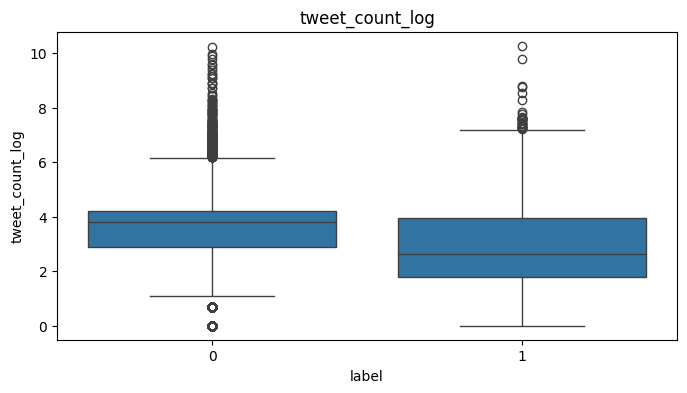

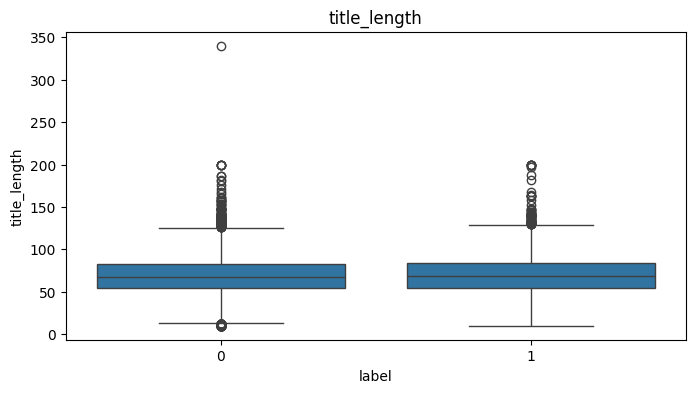

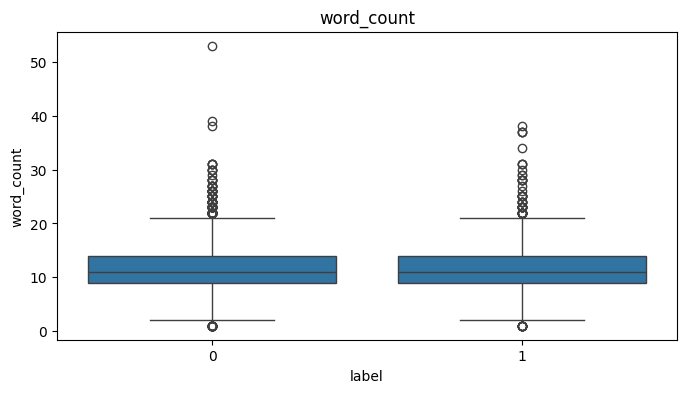

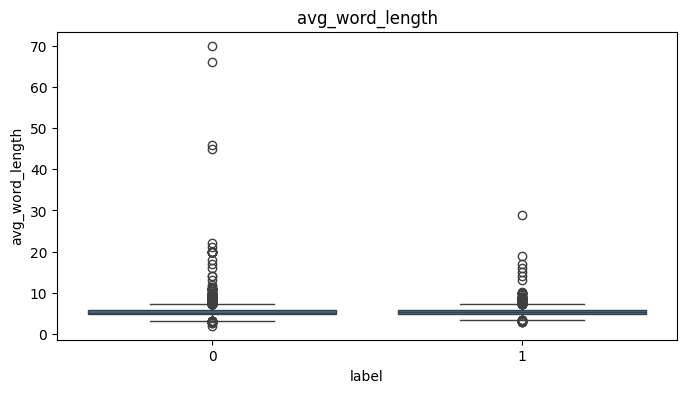

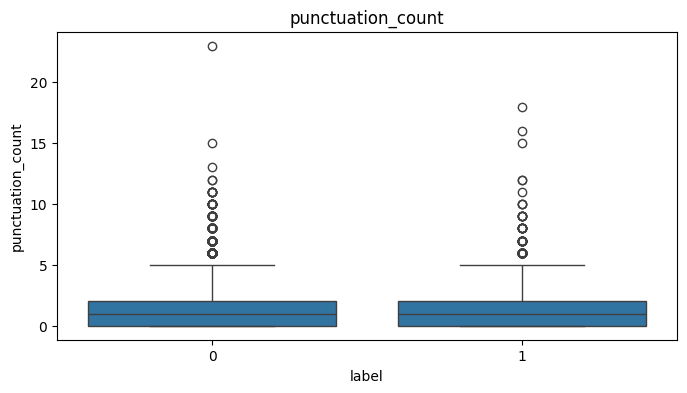

In [ ]:
features = [
    "tweet_count_log",
    "title_length",
    "word_count",
    "avg_word_length",
    "punctuation_count"
]

for col in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x="label",
        y=col,
        data=df
    )

    plt.title(col)

    plt.show()

False Positive vs False Negative Analysis

In [ ]:
errors = pd.DataFrame({

    "Actual":y_test,

    "Predicted":voting_pred,

    "Probability":voting_prob

})

fp = errors[
    (errors.Actual==0) &
    (errors.Predicted==1)
]

fn = errors[
    (errors.Actual==1) &
    (errors.Predicted==0)
]

print("False Positives:",len(fp))

print("False Negatives:",len(fn))

False Positives: 291
False Negatives: 281


Model Complexity Comparison

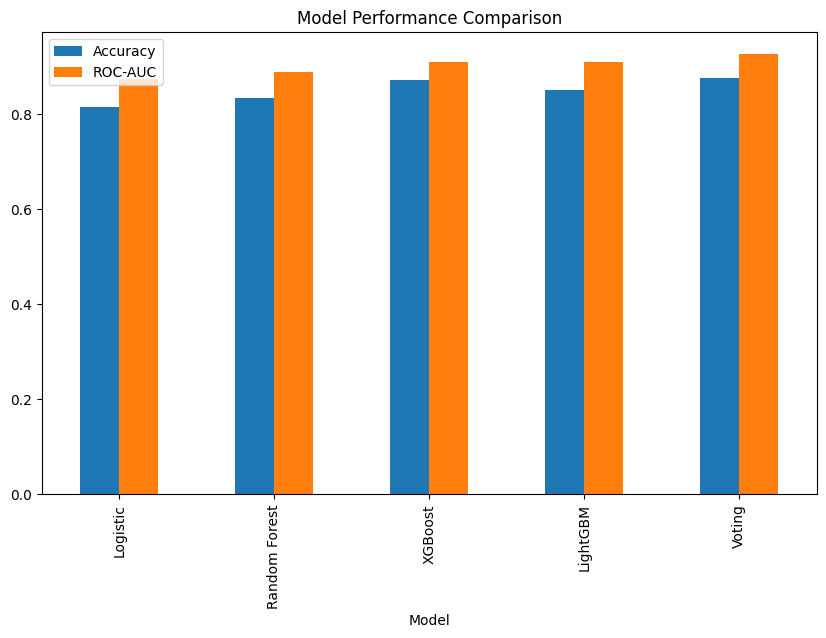

In [ ]:
comparison = pd.DataFrame({

"Model":[
"Logistic",
"Random Forest",
"XGBoost",
"LightGBM",
"Voting"
],

"Accuracy":[
accuracy_score(y_test,y_pred),
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,xgb_pred),
accuracy_score(y_test,lgbm_pred),
accuracy_score(y_test,voting_pred)
],

"ROC-AUC":[
roc_auc_score(y_test,y_prob),
roc_auc_score(y_test,rf_prob),
roc_auc_score(y_test,xgb_prob),
roc_auc_score(y_test,lgbm_prob),
roc_auc_score(y_test,voting_prob)
]

})

comparison.plot(
    x="Model",
    y=["Accuracy","ROC-AUC"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.show()